# Test of the Hyperview dataset

Regression task to estimate soil parameters (4)

In [1]:
import sys
import os

os.chdir(os.path.abspath('..'))
%load_ext autoreload
%autoreload 2

# Calculate the project root directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f"Adding {project_root} to sys.path")

# Add to sys.path -> necessary for importing the src package
if project_root not in sys.path:
    sys.path.append(project_root)

Adding /home/ando to sys.path


## Create splits 

If using for the first time: will save the splits to the root/splits directory

In [ ]:
from geofm_src.datasets.hyperview_wrapper import HyperviewBenchmark

dataset = HyperviewBenchmark(root='/data/panopticon/datasets/hyperview', create_splits=True)


/data/panopticon/datasets/hyperview/splits/train.csv


In [6]:
from geofm_src.datasets.hyperview_wrapper import HyperviewBenchmark
ds_hyp = HyperviewBenchmark(root='/data/panopticon/datasets/hyperview_10b', split='train')
ds_hyp.df




/home/ando/.conda/envs/fm/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


[HyperviewBenchmark] Building dataset for split: train


ValueError: Split file does not exist. Please create it first.

In [4]:
import random 
import matplotlib.pyplot as plt

image, label = ds_hyp[random.randint(0, len(ds_hyp))]


band_id = 100

(image,mask), _  = ds_hyp[20]
print(image.shape, label)
sample = image[band_id]

# image = (image - image.min()) / (image.max() - image.min())

# ds_hyp.plot(image)

plt.imshow(mask[128])
#show colorbar
plt.colorbar()


NameError: name 'ds_hyp' is not defined

In [91]:
#calculate the mode across the channels
import torch
mode = torch.mode(mask, dim=0)
mode


torch.return_types.mode(
values=tensor([[ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
          True],
        [ True,  True,  True, False, False, False, False, False,  True,  True,
          True],
        [ True,  True, False, False, False, False, False, False, False, False,
          True],
        [ True, False, False, False, False, False, False, False, False, False,
          True],
        [ True, False, False, False, False, False, False, False, False, False,
          True],
        [ True, False, False, False, False, False, False, False, False, False,
         False],
        [ True, False, False, False, False, False, False, False, False, False,
          True],
        [ True, False, False, False, False, False, False, False, False, False,
          True],
        [ True,  True, False, False, False, False, False, False, False, False,
          True],
        [ True,  True,  True, False, False, False, False, False, False,  True,
          True],
        

In [68]:
sample

masked_array(
  data=[[--, --, --, --, --, --, --, --, --, --, --],
        [--, --, --, 2752, 2432, 2471, 2200, 2077, --, --, --],
        [--, --, 3269, 2360, 2597, 2402, 2123, 2035, 2013, 1505, --],
        [--, 3305, 3093, 2222, 2396, 2437, 2209, 2226, 2092, 1804, --],
        [--, 3146, 2947, 2142, 2284, 2500, 2506, 2292, 2241, 1835, --],
        [--, 3130, 2724, 2179, 2340, 2601, 2405, 2147, 2073, 2021, 2003],
        [--, 3255, 2847, 2259, 2488, 2608, 2485, 2205, 2059, 2067, --],
        [--, 3150, 2768, 2276, 2358, 2616, 2479, 2294, 1799, 1781, --],
        [--, --, 2729, 2212, 2253, 2745, 2548, 2270, 1800, 1926, --],
        [--, --, --, 2267, 2324, 2743, 2663, 2498, 2140, --, --],
        [--, --, --, --, --, 2790, --, --, --, --, --]],
  mask=[[ True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True],
        [ True,  True,  True, False, False, False, False, False,  True,
          True,  True],
        [ True,  True, False, False, False, False, 

[HyperviewBenchmark] Building dataset for split: val
torch.Size([150, 11, 11]) tensor([ 0.4750,  0.1639, -0.1615,  0.5529])
tensor(403.) tensor(1588.)


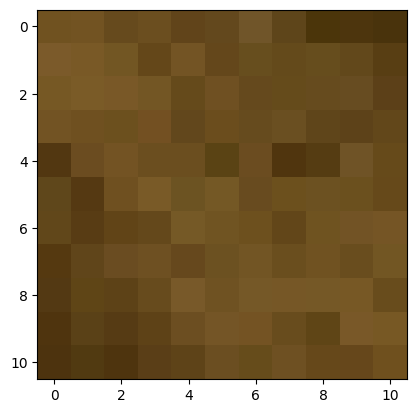

In [9]:
from geofm_src.datasets.hyperview_wrapper import HyperviewBenchmark
import matplotlib.pyplot as plt
import random

ds_hyp = HyperviewBenchmark(root='/data/panopticon/datasets/hyperview', split='val', normalize=False)

image, label = ds_hyp[random.randint(0, len(ds_hyp))]
print(image.shape, label)
print(image.min(), image.max())

image = (image - image.min()) / (image.max() - image.min())

ds_hyp.plot(image)




/data/panopticon/datasets/hyperview/splits/test.csv
torch.Size([150, 46, 48]) tensor([ 63.8000, 316.0000, 161.0000,   6.4000], dtype=torch.float64)


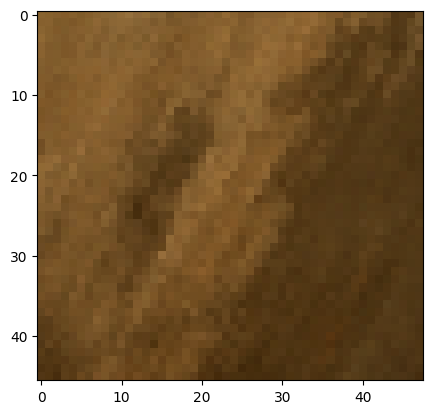

In [50]:
from src.datasets.hyperview_wrapper import HyperviewBenchmark

ds_hyp = HyperviewBenchmark(root='/data/panopticon/datasets/hyperview', split='test')
image, label = ds_hyp[random.randint(0, len(ds_hyp))]
print(image.shape, label)

image = (image - image.min()) / (image.max() - image.min())

ds_hyp.plot(image)




# Check dataset 

In [2]:
from omegaconf import OmegaConf
from geofm_src.factory import create_dataset
# read in a config file from the configs/dataset folder
ds_cfg = OmegaConf.load('geofm_src/configs/dataset/hyperview_sd.yaml')

train_ds, val_ds, test_ds = create_dataset(ds_cfg)
print((ds_cfg))

/home/ando/.conda/envs/fm/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


[ClsDataAugmentation: train] Simulating channels: tensor([[443,   7],
        [490,  20],
        [532,  14],
        [565,  15],
        [611,   9],
        [665,  12],
        [706,   6],
        [864,  15]])
[ClsDataAugmentation: val/test] Simulating channels: tensor([[443,   7],
        [490,  20],
        [532,  14],
        [565,  15],
        [611,   9],
        [665,  12],
        [706,   6],
        [864,  15]])
[HyperviewBenchmark] Building dataset for split: train
[HyperviewBenchmark] Building dataset for split: val
[HyperviewBenchmark] Building dataset for split: test
{'defaults': ['base_dataset'], 'dataset_type': 'hyperview', 'task': 'regression', 'dataset_name': 'hyperview', 'num_classes': 4, 'num_channels': 8, 'data_path': '${oc.env:DATASETS_DIR}/hyperview', 'image_resolution': 224, 'target_dataset_name': 'dummy-superdove', 'band_ids': [0, 1, 2, 3, 4, 5, 6, 7], 'senpamae_srf_name': 'rfs_superdove.npy', 'normalize_target': False, 'senpamae_channels': [0, 1, 2, 3, 4, 5, 6,

In [5]:
import random
import matplotlib.pyplot as plt
image, label = train_ds[random.randint(0, len(train_ds))]
print(image.shape, label)
print(image.min(), image.max())



# plt.imshow(image[55], vmin=-1, vmax=1)
# #colorbar values b/w -1 and 1
# plt.colorbar()
# plt.show()
# plt.imshow(image[-1], vmin=-1, vmax=1)
# plt.colorbar()
# plt.show()
# image = (image - image.min()) / (image.max() - image.min())

# train_ds.plot(image)


torch.Size([8, 224, 224]) tensor([ 76.4000, 198.0000, 138.0000,   7.1000])
tensor(0.) tensor(10.6407)


/home/ando/fm-playground/geofm_src/datasets/utils/utils.py:87: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target_srf_mean = torch.tensor(target_srf_mean, device=source_img.device)
/home/ando/fm-playground/geofm_src/datasets/utils/utils.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target_srf_std = torch.tensor(target_srf_std, device=source_img.device)


# Calculate the mean and std of the dataset using train and val splits

100%|██████████| 174/174 [00:10<00:00, 16.40it/s]


Mean per channel: tensor([ 357.3309,  356.8241,  352.2739,  359.0434,  367.4655,  384.4400,
         393.9638,  394.4952,  396.3852,  398.7393,  403.4731,  410.9720,
         416.7098,  432.1976,  446.6424,  454.2320,  463.8037,  473.5013,
         483.0237,  483.5212,  491.3178,  506.2690,  528.5842,  553.2881,
         566.9301,  575.3107,  587.1912,  594.3837,  605.8002,  613.8228,
         624.9483,  633.2333,  639.2795,  642.0591,  641.8145,  642.4167,
         648.9135,  653.1238,  660.5588,  669.0240,  678.0240,  683.0078,
         687.1527,  689.9290,  696.5694,  703.5454,  707.0600,  706.4673,
         709.4718,  713.4590,  719.6038,  723.9843,  726.3781,  726.3223,
         730.5421,  735.3784,  740.7471,  754.7546,  761.3821,  758.1700,
         750.7112,  741.2469,  735.4827,  733.5818,  738.0514,  731.8038,
         728.2272,  732.5236,  743.2369,  774.4900,  816.4062,  864.4771,
         911.8911,  952.4366,  984.7453, 1013.8170, 1051.8807, 1087.1163,
        1122.3405, 1

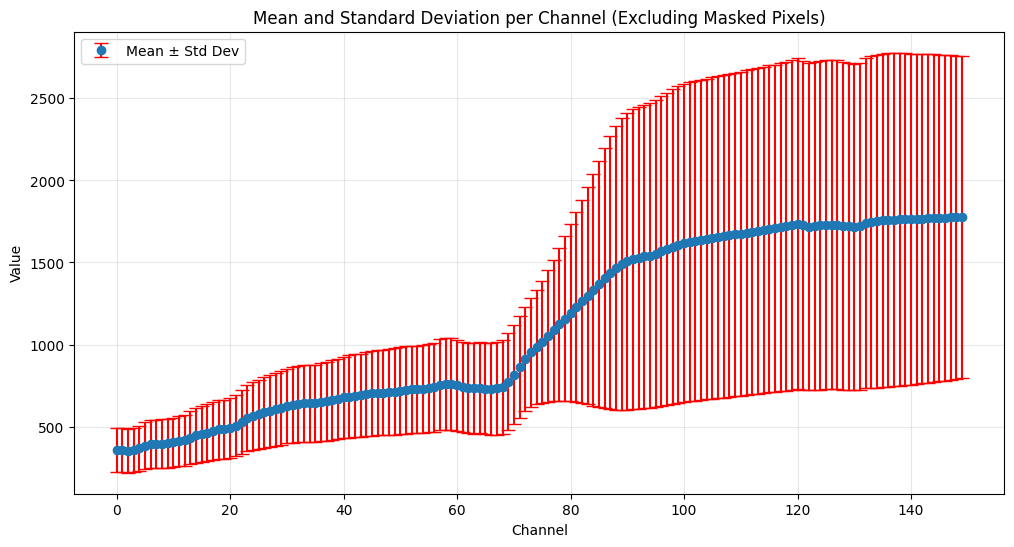

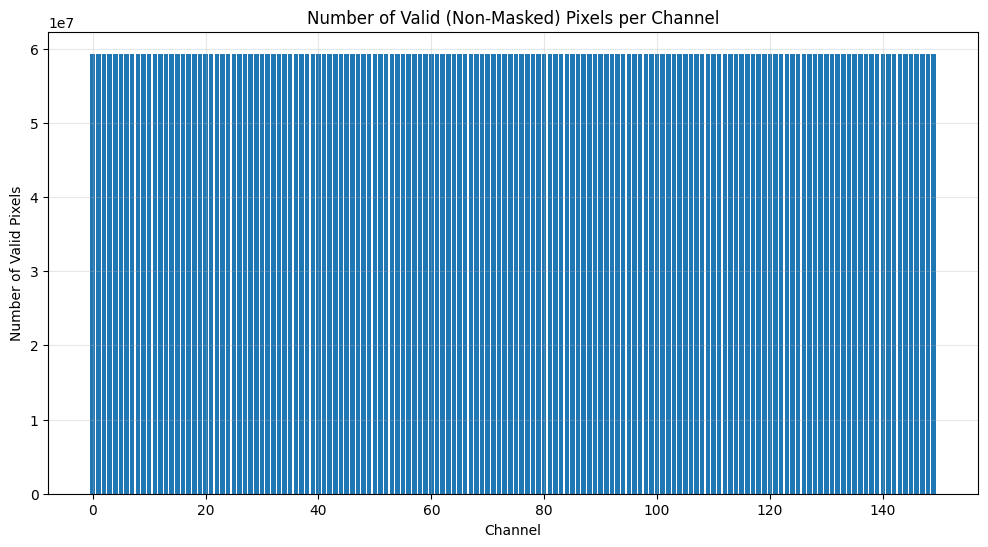

In [12]:
import numpy as np
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt

# Calculate the channel-wise mean and std of the train and val sets
# Properly handling masked pixels (zeros)

# Image stats
C = train_ds.num_channels
sum_per_channel = torch.zeros(C)
sum_of_squares_per_channel = torch.zeros(C)
num_valid_pixels_per_channel = torch.zeros(C)  # Track valid pixels per channel

# Label stats
sum_per_label = torch.zeros(4)
sum_of_squares_per_label = torch.zeros(4)
labels_max = torch.zeros(4)
labels_min = torch.ones(4) * 10000
num_images = 0

# Train set
for i in tqdm(range(len(train_ds))):
    img, label = train_ds[i]
    
    # Create mask for non-zero pixels (assuming 0 indicates masked pixels)
    mask = (img != 0)
    
    # Process each channel separately
    for c in range(C):
        channel_data = img[c]
        channel_mask = mask[c]
        
        # Only include non-masked pixels in calculations
        valid_pixels = channel_data[channel_mask]
        sum_per_channel[c] += valid_pixels.sum()
        sum_of_squares_per_channel[c] += (valid_pixels ** 2).sum()
        num_valid_pixels_per_channel[c] += valid_pixels.size(0)
    
    # Label statistics remain the same
    sum_per_label += label
    sum_of_squares_per_label += label ** 2
    num_images += 1
    labels_max = torch.max(labels_max, label)
    labels_min = torch.min(labels_min, label)
    
# Val set
for i in tqdm(range(len(val_ds))):
    img, label = val_ds[i]
    
    # Create mask for non-zero pixels
    mask = (img != 0)
    
    # Process each channel separately
    for c in range(C):
        channel_data = img[c]
        channel_mask = mask[c]
        
        # Only include non-masked pixels in calculations
        valid_pixels = channel_data[channel_mask]
        sum_per_channel[c] += valid_pixels.sum()
        sum_of_squares_per_channel[c] += (valid_pixels ** 2).sum()
        num_valid_pixels_per_channel[c] += valid_pixels.size(0)
    
    num_images += 1
    labels_max = torch.max(labels_max, label)
    labels_min = torch.min(labels_min, label)

# Compute mean and standard deviation using only valid pixels
mean_per_channel = sum_per_channel / num_valid_pixels_per_channel
var_per_channel = (sum_of_squares_per_channel / num_valid_pixels_per_channel) - (mean_per_channel ** 2)
std_per_channel = torch.sqrt(var_per_channel)

mean_per_label = sum_per_label / num_images
std_per_label = torch.sqrt(sum_of_squares_per_label / num_images - mean_per_label ** 2)

print("Mean per channel:", mean_per_channel)
print("Standard deviation per channel:", std_per_channel)
print("Number of valid pixels per channel:", num_valid_pixels_per_channel)

print("Mean per label:", mean_per_label)
print("Standard deviation per label:", std_per_label)
print("Max per label:", labels_max)
print("Min per label:", labels_min)
print("Number of images:", num_images)

# Visualization
channels = np.arange(C)
mean_values = mean_per_channel.numpy()
std_values = std_per_channel.numpy()

plt.figure(figsize=(12, 6))
plt.errorbar(channels, mean_values, yerr=std_values, fmt='o', ecolor='r', capsize=5, label='Mean ± Std Dev')
plt.xlabel('Channel')
plt.ylabel('Value')
plt.title('Mean and Standard Deviation per Channel (Excluding Masked Pixels)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Optional: Plot the number of valid pixels per channel
plt.figure(figsize=(12, 6))
plt.bar(channels, num_valid_pixels_per_channel.numpy())
plt.xlabel('Channel')
plt.ylabel('Number of Valid Pixels')
plt.title('Number of Valid (Non-Masked) Pixels per Channel')
plt.grid(True, alpha=0.3)
plt.show()

100%|██████████| 174/174 [00:04<00:00, 37.91it/s]


Mean per channel: tensor([0.3911, 0.3909, 0.3902, 0.3909, 0.3917, 0.3934, 0.3941, 0.3938, 0.3935,
        0.3930, 0.3927, 0.3926, 0.3925, 0.3932, 0.3937, 0.3938, 0.3941, 0.3944,
        0.3947, 0.3943, 0.3942, 0.3944, 0.3949, 0.3956, 0.3956, 0.3956, 0.3958,
        0.3958, 0.3960, 0.3961, 0.3964, 0.3965, 0.3966, 0.3964, 0.3961, 0.3958,
        0.3955, 0.3953, 0.3951, 0.3951, 0.3952, 0.3951, 0.3951, 0.3951, 0.3952,
        0.3952, 0.3952, 0.3950, 0.3949, 0.3948, 0.3948, 0.3949, 0.3951, 0.3953,
        0.3956, 0.3958, 0.3958, 0.3957, 0.3953, 0.3947, 0.3940, 0.3931, 0.3921,
        0.3911, 0.3900, 0.3891, 0.3878, 0.3865, 0.3864, 0.3888, 0.3934, 0.3988,
        0.4028, 0.4035, 0.4008, 0.3955, 0.3897, 0.3824, 0.3745, 0.3665, 0.3584,
        0.3506, 0.3431, 0.3357, 0.3285, 0.3217, 0.3157, 0.3107, 0.3070, 0.3047,
        0.3035, 0.3031, 0.3031, 0.3030, 0.3029, 0.3028, 0.3027, 0.3028, 0.3031,
        0.3034, 0.3038, 0.3042, 0.3046, 0.3049, 0.3052, 0.3055, 0.3059, 0.3062,
        0.3065, 0.3069

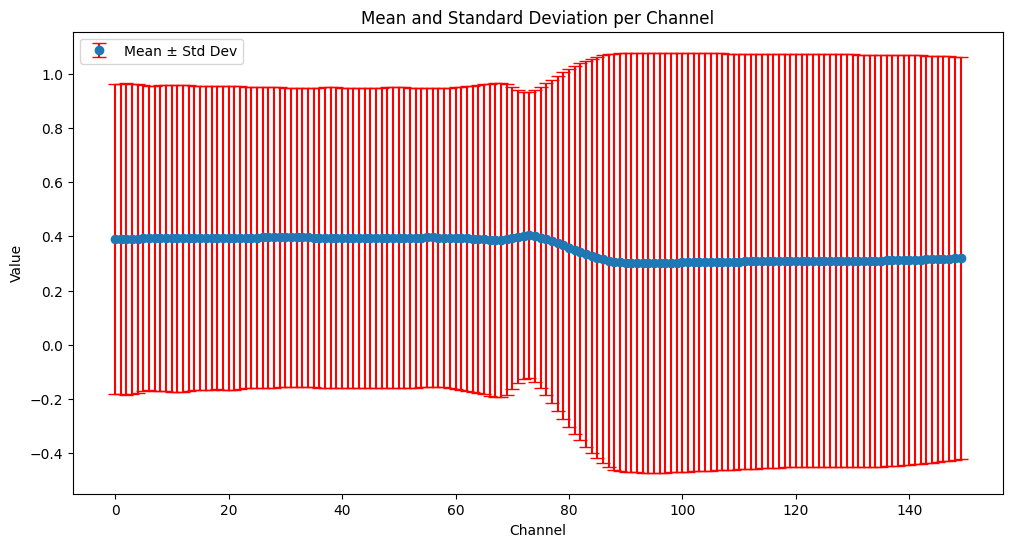

In [188]:
import numpy as np
import torch
from tqdm import tqdm

# calculate the channel-wise mean and std of the train set
#ARTIFICALLY turn off normalize before you do this obvs!

# Image stats
C = train_ds.num_channels
sum_per_channel = torch.zeros(C)
sum_of_squares_per_channel = torch.zeros(C)
num_samples = 0

#Label stats
sum_per_label = torch.zeros(4)
sum_of_squares_per_label = torch.zeros(4)
labels_max = torch.zeros(4)
labels_min = torch.ones(4) * 10000
num_images = 0

#train set
for i in tqdm(range(len(train_ds))):

    img, label = train_ds[i]
    # Accumulate sum and sum of squares
    sum_per_channel += img.view(C, -1).sum(dim=1)
    sum_of_squares_per_channel += (img.view(C, -1) ** 2).sum(dim=1)
    num_samples += img.shape[1] * img.shape[2]

    sum_per_label += label
    sum_of_squares_per_label += label ** 2
    num_images += 1
    labels_max = torch.max(labels_max, label)
    labels_min = torch.min(labels_min, label)
    
# val set
for i in tqdm(range(len(val_ds))):
    img, label = val_ds[i]
    # Accumulate sum and sum of squares
    sum_per_channel += img.view(C, -1).sum(dim=1)
    sum_of_squares_per_channel += (img.view(C, -1) ** 2).sum(dim=1)
    num_samples += img.shape[1] * img.shape[2]
    num_images += 1
    labels_max = torch.max(labels_max, label)
    labels_min = torch.min(labels_min, label)

# Compute mean and standard deviation
mean_per_channel = sum_per_channel / num_samples
std_per_channel = torch.sqrt(sum_of_squares_per_channel / num_samples - mean_per_channel ** 2)

mean_per_label = sum_per_label / num_images
std_per_label = torch.sqrt(sum_of_squares_per_label / num_images - mean_per_label ** 2)

print("Mean per channel:", mean_per_channel)
print("Standard deviation per channel:", std_per_channel)
print("Number of samples:", num_samples)

print("Mean per label:", mean_per_label)
print("Standard deviation per label:", std_per_label)
print("Max per label:", labels_max)
print("Min per label:", labels_min)
print("Number of images:", num_images)

channels = np.arange(C)
mean_values = mean_per_channel.numpy()
std_values = std_per_channel.numpy()

plt.figure(figsize=(12, 6))
plt.errorbar(channels, mean_values, yerr=std_values, fmt='o', ecolor='r', capsize=5, label='Mean ± Std Dev')
plt.xlabel('Channel')
plt.ylabel('Value')
plt.title('Mean and Standard Deviation per Channel')
plt.legend()
plt.show()

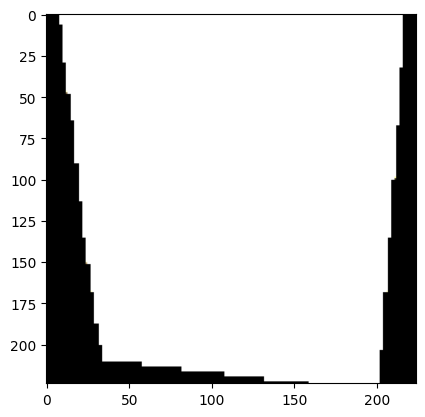

In [140]:
train_ds.plot(img)

# Check if normalize is working

In [20]:
from omegaconf import OmegaConf
from geofm_src.factory import create_dataset
# read in a config file from the configs/dataset folder
ds_cfg = OmegaConf.load('geofm_src/configs/dataset/hyperview_10b.yaml')

train_ds, val_ds, test_ds = create_dataset(ds_cfg)

[ClsDataAugmentation: train] Sampling channels: [6, 18, 42, 59, 70, 82, 102, 109, 126, 144]
[ClsDataAugmentation: val/test] Sampling channels: [6, 18, 42, 59, 70, 82, 102, 109, 126, 144]
[HyperviewBenchmark] Building dataset for split: train
[HyperviewBenchmark] Building dataset for split: val
[HyperviewBenchmark] Building dataset for split: test


In [26]:
import random
image, label = train_ds[random.randint(0, len(test_ds))]
print(image.shape, label)

print(image.min(), image.max())

# image = (image - image.min()) / (image.max() - image.min())

# train_ds.plot(image)


torch.Size([10, 224, 224]) tensor([0.5843, 0.0576, 0.9266, 0.2807])
tensor(-1.2017) tensor(1.7332)


## Channel Binning

In [13]:
# import numpy as np
#set seed
np.random.seed(42)

num_channels = 150
K = 10
# Calculate bin size
bin_size = num_channels // K
# Create bins and select random values from each
selected_channels = []
for i in range(K):
    start = i * bin_size
    end = start + bin_size if i < K-1 else num_channels  # Handle last bin differently
    selected_channels.append(np.random.randint(start, end))

print(f"Selected channels: {sorted(selected_channels)}")


Selected channels: [6, 18, 42, 59, 70, 82, 102, 109, 126, 144]


In [2]:
import numpy as np
#set seed
np.random.seed(42)

num_channels = 202
K = 50
# Calculate bin size
bin_size = num_channels // K
# Create bins and select random values from each
selected_channels = []
for i in range(K):
    start = i * bin_size
    end = start + bin_size if i < K-1 else num_channels  # Handle last bin differently
    selected_channels.append(np.random.randint(start, end))

print(f"Selected channels: {sorted(selected_channels)}")


Selected channels: [2, 7, 8, 14, 18, 23, 24, 28, 34, 37, 42, 46, 50, 54, 59, 60, 67, 71, 75, 78, 81, 84, 89, 95, 99, 101, 105, 109, 115, 119, 120, 124, 131, 133, 137, 140, 147, 148, 152, 158, 162, 166, 169, 175, 179, 183, 187, 190, 193, 201]
